In [1]:
#Importando as bibliotecas
import pandas as pd
import folium
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

# 1) Análise baseada em Jones et al. (2020)

In [2]:
#Reference: https://essd.copernicus.org/articles/13/237/2021/
#Reference: Jones et al. (2021)

ww_production = pd.read_csv('./datasets/global_wastewater_production.csv')
ww_production['WWuc_million_m3_yr'] = ww_production['WWp_million_m3_yr'] - ww_production['WWc_million_m3_yr']
ww_10producers = ww_production.sort_values('WWp_million_m3_yr', ascending = False).head(10)
ww_production['Economic_Classification'] = pd.Categorical(ww_production['Economic_Classification'], categories = ['Low income', 'Lower middle income', 'Upper middle income', 'High income'])
ww_production = ww_production.sort_values('Economic_Classification').reset_index(drop=True)

#Variação na produção de água residual por país agrupado por classificação econômica
grupos_economic_classification = ww_production[['Economic_Classification', 'WWp_million_m3_yr']].groupby('Economic_Classification').median().reset_index()

/tmp/ipykernel_1276/132932644.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos_economic_classification = ww_production[['Economic_Classification', 'WWp_million_m3_yr']].groupby('Economic_Classification').median().reset_index()


In [3]:
ww_10producers

,Country,Region,Economic_Classification,WWp_million_m3_yr,WWc_million_m3_yr,WWt_million_m3_yr,WWr_million_m3_yr,WWuc_million_m3_yr
0,United States,North America,High income,67600.0,52879.16,45779.02,8831.23,14720.84
1,China,East Asia & Pacific,Upper middle income,63700.0,31226.57,31226.57,8603.24,32473.43
2,India,Southern Asia,Lower middle income,18600.0,6091.12,3576.44,521.56,12508.88
3,Brazil,Latin America & Caribbean,Upper middle income,18500.0,10152.38,7544.94,123.90,8347.62
4,Indonesia,East Asia & Pacific,Lower middle income,13800.0,6263.75,4122.16,630.77,7536.25
5,Japan,East Asia & Pacific,High income,12200.0,8626.78,8626.78,97.62,3573.22
6,Egypt,Middle East & North Africa,Lower middle income,11300.0,10389.23,6416.88,2652.76,910.77
7,Russian Federation,Eastern Europe & Central Asia,Upper middle income,9500.0,5237.01,5237.01,560.64,4262.99
8,Mexico,Latin America & Caribbean,Upper middle income,7550.0,6925.46,3277.70,1514.99,624.54
9,Germany,Western Europe,High income,7510.0,7466.03,7285.76,1876.37,43.97


In [4]:
grupos_economic_classification

,Economic_Classification,WWp_million_m3_yr
0,Low income,63.5
1,Lower middle income,175.5
2,Upper middle income,255.0
3,High income,232.5


/tmp/ipykernel_1797/937456254.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = ['Low income', 'Lower middle income', 'Upper middle income', 'High income'], rotation = 90)


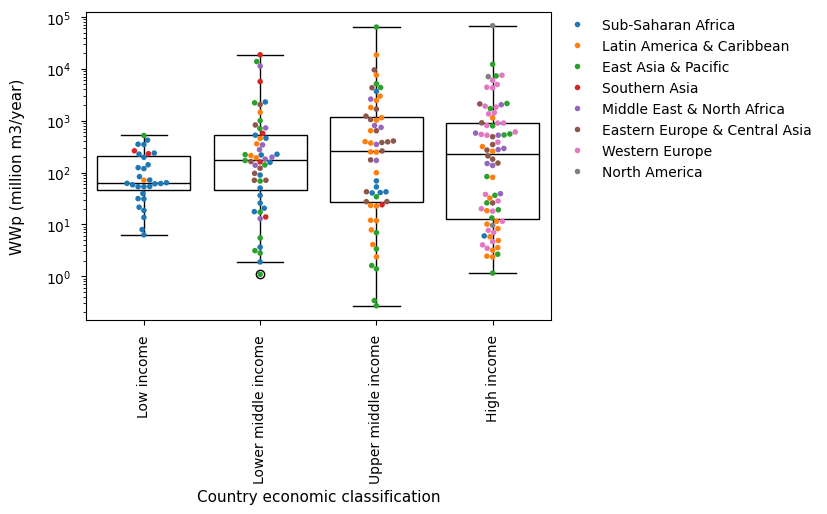

In [5]:
fig1, ax = plt.subplots(figsize = (6,4))

sns.boxplot(ww_production, x = ww_production['Economic_Classification'], y = ww_production['WWp_million_m3_yr'], fill = True, color = 'white', linecolor = 'black', log_scale = True, ax = ax)
sns.swarmplot(ww_production, x = ww_production['Economic_Classification'], y = ww_production['WWp_million_m3_yr'], size = 4, edgecolor = 'red', hue = 'Region', ax = ax)

ax.set_ylabel('WWp (million m3/year)', fontsize=11)
ax.set_xlabel('Country economic classification', fontsize=11)
ax.tick_params(axis = 'both', pad = 7)
ax.set_xticklabels(labels = ['Low income', 'Lower middle income', 'Upper middle income', 'High income'], rotation = 90)
ax.yaxis.labelpad = 15
ax.legend(frameon = False)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1.02))
fig1.savefig('images/boxplot_1', bbox_inches='tight')

#ax.set_xticklabels(labels = ['Low', 'Chuvoso'])
#ax.set_ticks(ticks = ['Low income', 'Lower middle income', 'Upper middle income', 'High income'])

## 1.1.) Variação na produção de água residual entre os países

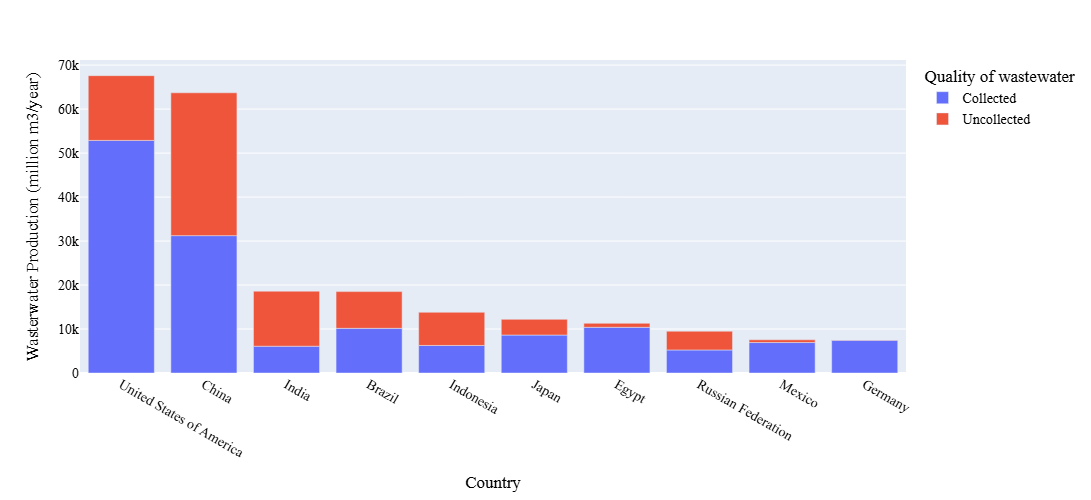

In [6]:
df = pd.DataFrame({'nation': ['United States of America', 'China', 'India', 'Brazil', 'Indonesia', 'Japan', 'Egypt', 'Russian Federation', 'Mexico', 'Germany',
                              'United States of America', 'China', 'India', 'Brazil', 'Indonesia', 'Japan', 'Egypt', 'Russian Federation', 'Mexico', 'Germany'],
         'ww_volume': ['Collected', 'Collected', 'Collected', 'Collected', 'Collected', 'Collected', 'Collected', 'Collected', 'Collected', 'Collected', 
                        'Uncollected', 'Uncollected', 'Uncollected', 'Uncollected', 'Uncollected', 'Uncollected', 'Uncollected', 'Uncollected', 'Uncollected', 'Uncollected'],
         'wastewater': [52879.16, 31226.57, 6091.12, 10152.38, 6263.75, 8626.78, 10389.23, 5237.01, 6925.46, 7466.03, 
                        14720.84, 32473.43, 12508.88, 8347.62, 7536.25, 3573.22, 910.77, 4262.99, 624.54, 43.97]
                  }
                 )

fig4 = px.bar(df, 'nation', y = 'wastewater', color = 'ww_volume', width=700, height=500)

fig4.update_layout(
        font_family="Times New Roman",
        font_color="black",
        title_font_family="Times New Roman",
        title_font_color="black",
        legend_title_font_color="black"
    )
    
fig4.update_layout(
        xaxis=dict(
            title=dict(
                text="Country"
            )
        ),
        yaxis=dict(
            title=dict(
                text= 'Wasterwater Production (million m3/year)'
            )
        ),
        legend=dict(
            title=dict(
                text="Quality of wastewater"
            )
        ),
        font=dict(
            family="Times New Roman, monospace",
            size=14,
            color="black"
        )
    )

fig4.show()
#fig4.write_image("images/bargraph_1_collected_uncollected.png")

In [16]:
ww_10producers

,Country,Region,Economic_Classification,WWp_million_m3_yr,WWc_million_m3_yr,WWt_million_m3_yr,WWr_million_m3_yr,WWuc_million_m3_yr
0,United States,North America,High income,67600.0,52879.16,45779.02,8831.23,14720.84
1,China,East Asia & Pacific,Upper middle income,63700.0,31226.57,31226.57,8603.24,32473.43
2,India,Southern Asia,Lower middle income,18600.0,6091.12,3576.44,521.56,12508.88
3,Brazil,Latin America & Caribbean,Upper middle income,18500.0,10152.38,7544.94,123.90,8347.62
4,Indonesia,East Asia & Pacific,Lower middle income,13800.0,6263.75,4122.16,630.77,7536.25
5,Japan,East Asia & Pacific,High income,12200.0,8626.78,8626.78,97.62,3573.22
6,Egypt,Middle East & North Africa,Lower middle income,11300.0,10389.23,6416.88,2652.76,910.77
7,Russian Federation,Eastern Europe & Central Asia,Upper middle income,9500.0,5237.01,5237.01,560.64,4262.99
8,Mexico,Latin America & Caribbean,Upper middle income,7550.0,6925.46,3277.70,1514.99,624.54
9,Germany,Western Europe,High income,7510.0,7466.03,7285.76,1876.37,43.97


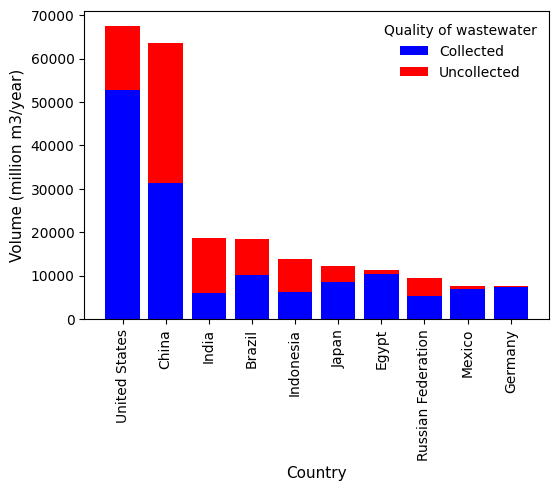

In [60]:
fig2, ax2 = plt.subplots(figsize = (6,4))

ax2.bar(ww_10producers['Country'], collected, color = 'blue')
ax2.bar(ww_10producers['Country'], uncollected, color = 'red', bottom = collected)
ax2.set_ylabel('Volume (million m3/year)', fontsize = 11)
ax2.set_xlabel('Country', fontsize = 11)

ax2.legend(['Collected', 'Uncollected'], frameon = False, title = 'Quality of wastewater')

ax2.tick_params(axis = 'x', labelrotation = 90)

# 2) Análise baseada em Macedo et al. (2021)

In [5]:
#Carregando arquivo csv
df = pd.read_csv('./hydrowaste/database.csv', encoding='latin-1')

#Filtrando as linhas referentes a estações localizadas a no máximo 10 km do oceano ou de grandes lagos
df1 = df.loc[df['COAST_10KM'] == 1, ['COUNTRY', 'WASTE_ID']]

contagem_ww_plants = []
countries = list(ww_10producers['Country'])
countries[7] = 'Russia'

for country in countries:

    df2 = df1.loc[df1['COUNTRY'] == country, ['COUNTRY', 'WASTE_ID']]
    lista = [df2['COUNTRY'].unique()[0], df2['WASTE_ID'].count()]
    contagem_ww_plants.append(lista)

contagem_ww_plants = pd.DataFrame(contagem_ww_plants, columns =['Country', 'Quantity'])
contagem_ww_plants

,Country,Quantity
0,United States,1287
1,China,307
2,India,86
3,Brazil,685
4,Indonesia,22
5,Japan,235
6,Egypt,17
7,Russia,186
8,Mexico,383
9,Germany,184


In [34]:
coastline = [19924, 14500, 7000, 7491, 54716, 29751, 2450, 37653, 9330, 2389] #Reference: https://www.cia.gov/the-world-factbook/field/coastline/
population = [341963408, 1416043270, 1409128296 ,  220051512, 281562465, 123201945, 111247248, 140820810, 130739927, 84119100] #https://www.cia.gov/the-world-factbook/field/population/

contagem_ww_plants['Coastline (km)'] = coastline
contagem_ww_plants['Population'] = population

contagem_ww_plants

,Country,Quantity,Coastline (km),Population
0,United States,1287,19924,341963408
1,China,307,14500,1416043270
2,India,86,7000,1409128296
3,Brazil,685,7491,220051512
4,Indonesia,22,54716,281562465
5,Japan,235,29751,123201945
6,Egypt,17,2450,111247248
7,Russia,186,37653,140820810
8,Mexico,383,9330,130739927
9,Germany,184,2389,84119100


/tmp/ipykernel_1276/1469377370.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = ['United States', 'China', 'India', 'Brazil', 'Indonesia', 'Japan', 'Egypt', 'Russia', 'Mexico', 'Germany'], rotation = 90)


[Text(0, 0, 'United States'),
 Text(1, 0, 'China'),
 Text(2, 0, 'India'),
 Text(3, 0, 'Brazil'),
 Text(4, 0, 'Indonesia'),
 Text(5, 0, 'Japan'),
 Text(6, 0, 'Egypt'),
 Text(7, 0, 'Russia'),
 Text(8, 0, 'Mexico'),
 Text(9, 0, 'Germany')]

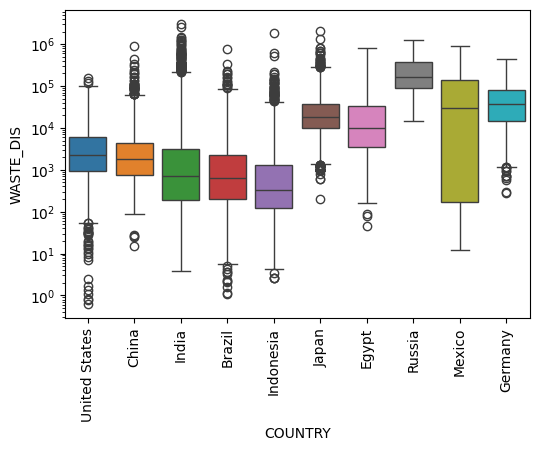

In [11]:
df4 = df.loc[(df['COUNTRY'] == 'United States')|
              (df['COUNTRY'] == 'China') |
              (df['COUNTRY'] == 'India') |
              (df['COUNTRY'] == 'Brazil') |
              (df['COUNTRY'] == 'Indonesia') |
              (df['COUNTRY'] == 'Japan') |
              (df['COUNTRY'] == 'Egypt') |
              (df['COUNTRY'] == 'Russia') |
              (df['COUNTRY'] == 'Mexico') |
              (df['COUNTRY'] == 'Germany'), :]

fig, ax = plt.subplots(figsize = (6, 4))
sns.boxplot(df4, x = df4['COUNTRY'], y = df4['WASTE_DIS'], hue = df4['COUNTRY'], log_scale = True)
ax.set_xticklabels(labels = ['United States', 'China', 'India', 'Brazil', 'Indonesia', 'Japan', 'Egypt', 'Russia', 'Mexico', 'Germany'], rotation = 90)

In [16]:
#df1[['COUNTRY', 'WASTE_ID']].groupby('COUNTRY').count().sort_values('WASTE_ID', ascending=False).reset_index()
brasil = df.loc[(df['COAST_10KM'] == 1)&(df['COUNTRY'] == 'Germany'), :]
#brasil.unique()

In [17]:
map = folium.Map(location = [brasil['LON_OUT'].median(), brasil['LAT_OUT'].median()], tiles = 'OpenStreetMap', zoom_start = 2)

for row, column in brasil.iterrows():

     folium.Marker(location = (brasil.loc[row, 'LAT_OUT'], brasil.loc[row, 'LON_OUT'])).add_to(map)

map   